### Задание

Самостоятельно напишите нейронную сеть, которая может стать составной частью системы бота для игры в "Крестики-нолики". Используя подготовленную базу изображений, создайте и обучите нейронную сеть, распознающую две категории изображений: крестики и нолики. Добейтесь точности распознавания более 95% (accuracy)


## Импорт всех необходимых библиотек

In [3]:
# Подключение класса для создания нейронной сети прямого распространения
from tensorflow.keras.models import Sequential
# Подключение класса для создания полносвязного слоя
from tensorflow.keras.layers import Dense
# Подключение оптимизатора
from tensorflow.keras.optimizers import Adam
# Подключение утилит для to_categorical
from tensorflow.keras import utils
# Подключение библиотеки для загрузки изображений
from tensorflow.keras.preprocessing import image
# Подключение библиотеки для работы с массивами
import numpy as np
# Подключение модуля для работы с файлами
import os
# Подключение skleart для разделения выборки на тестовую и тренировочную
from sklearn.model_selection import train_test_split
# Подключение библиотек для отрисовки изображений
import matplotlib.pyplot as plt
from PIL import Image
import random
# Вывод изображения в ноутбуке, а не в консоли или файле
%matplotlib inline

## Загрузка датасета

In [4]:
# Загрузка датасета из облака
import gdown
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l3/hw_pro.zip', None, quiet=True)

'hw_pro.zip'

In [5]:
# Распаковываем архив hw_light.zip в папку hw_light
!unzip -q hw_pro.zip

In [6]:
# Путь к директории с базой
base_dir = '/content/hw_pro'
# Создание пустого списка для загрузки изображений обучающей выборки
X = []
# Создание списка для меток классов
y = []
# Задание высоты и ширины загружаемых изображений
img_height = 20
img_width = 20
# Перебор папок в директории базы
for patch in os.listdir(base_dir):
    # Перебор файлов в папках
    for img in os.listdir(base_dir + '/' + patch):
        # Добавление в список изображений текущей картинки
        X.append(image.img_to_array(image.load_img(base_dir + '/' + patch + '/' + img,
                                                         target_size=(img_height, img_width),
                                                         color_mode='grayscale')))
        # Добавление в массив меток, соответствующих классам
        if patch == '0':
            y.append(0)
        else:
            y.append(1)
# Преобразование в numpy-массив загруженных изображений и меток классов
X = np.array(X)
y = np.array(y)
# Вывод размерностей
print('Размер массива x', X.shape)
print('Размер массива y', y.shape)

Размер массива x (102, 20, 20, 1)
Размер массива y (102,)


## Визуализация данных с помощью matplotlib

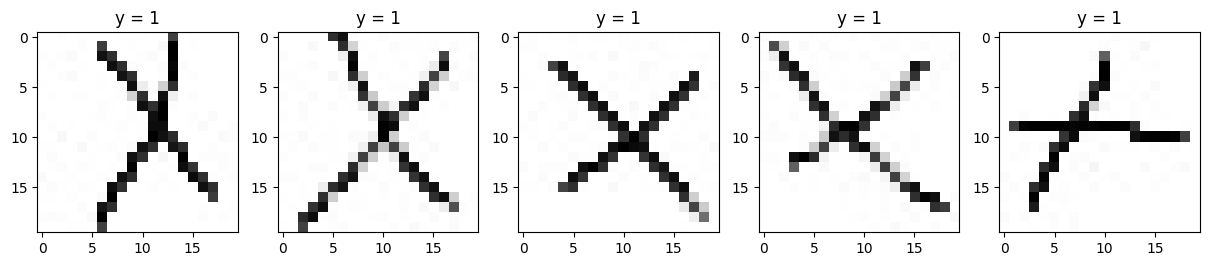

In [8]:
plt.figure(figsize=(15,6))

for i in range(5):
    plt.subplot(1, 5, i + 1)

    img = X[i].reshape(20, 20)

    plt.imshow(img, cmap='gray')
    plt.title(f"y = {y[i]}")

plt.show()

## Подготовка данных к обучению модели

In [9]:
# Преобразуем данные
X = X.reshape(X.shape[0], -1)
X = X.astype('float32') / 255.

# Преобразуем метки
CLASS_COUNT = 2
y = utils.to_categorical(y, CLASS_COUNT)

In [10]:
print(f"Размерность X: {X.shape}")
print(f"Вид данных меток y: {y[0]}")

Размерность X: (102, 400)
Вид данных меток y: [0. 1.]


## Разделение на тестовую и тренировочную выборку

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1
)

In [12]:
print(f"Размер X_test: {X_test.shape}")

Размер X_test: (21, 400)


## Создание модели

In [27]:
model = Sequential()

model.add(Dense(400, input_dim=400, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(CLASS_COUNT, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
print(model.summary())

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_30 (Dense)                │ (None, 400)            │       160,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │        25,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_34 (Dense)                │ (None, 2)              │            34 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 188,706 (737.13 KB)

 Trainable params: 188,706 (737.13 KB)

 Non-trainable params: 0 (0.00 B)

None


## Обучение модели

In [28]:
model.fit(X_train,
          y_train,
          batch_size=32,
          epochs=9,
          validation_data=(X_test, y_test),
          verbose=1)

Epoch 1/9
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 142ms/step - accuracy: 0.6173 - loss: 0.7019 - val_accuracy: 0.3810 - val_loss: 0.7012
Epoch 2/9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.6049 - loss: 0.6194 - val_accuracy: 0.4286 - val_loss: 0.6778
Epoch 3/9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.8765 - loss: 0.5413 - val_accuracy: 0.8571 - val_loss: 0.5600
Epoch 4/9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.8642 - loss: 0.4630 - val_accuracy: 0.8095 - val_loss: 0.5841
Epoch 5/9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.9259 - loss: 0.4048 - val_accuracy: 0.8095 - val_loss: 0.4967
Epoch 6/9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.9630 - loss: 0.3274 - val_accuracy: 0.9048 - val_loss: 0.3910
Epoch 7/9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 1.0000 - loss: 0.2602 - val_accuracy: 0.8571 - val_loss: 0.3931
Epoch 8/9
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 1.0000 - loss: 0.2182 - val_accuracy: 0.8571 - val_loss: 0.3674
Epoch 9

## Вывод оценки модели на тестовой выборке

In [29]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f'accuracy: {test_acc:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.9524 - loss: 0.2227
accuracy: 0.9524


## Вывод

Точность на тестовой выборке составила 0.9524 (95%)